Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

Load Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Missing Values

In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Descriptive Statistics

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Gender Distribution

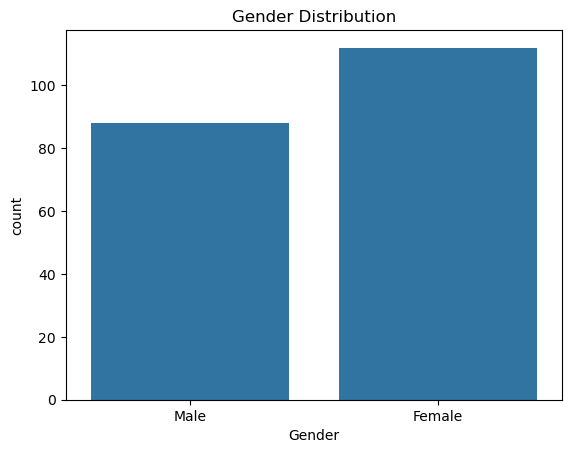

In [6]:
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")

plt.show()

Encode Gender

In [7]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


Correlation Heatmap

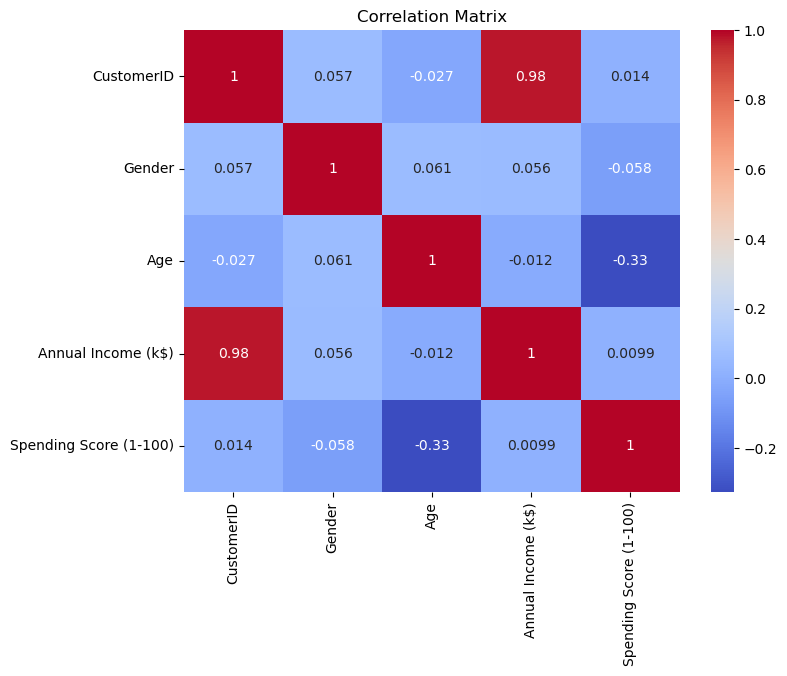

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

Customer Segmentation Features

In [9]:
X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Feature Scaling

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Elbow Method

In [11]:
wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

C:\Users\DS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

Elbow Plot

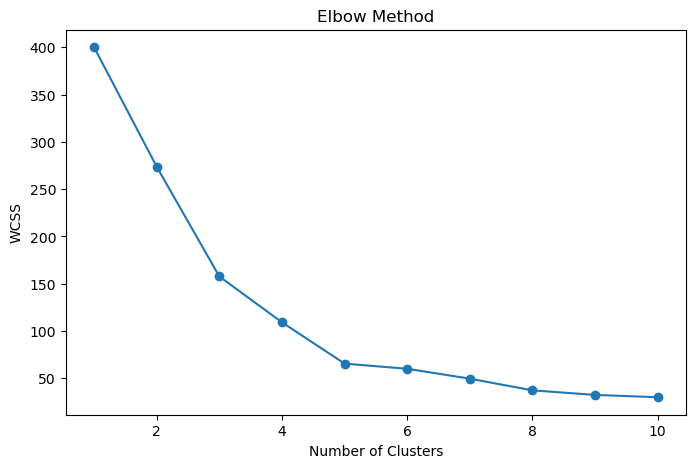

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

K-Means Clustering

In [13]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

C:\Users\DS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [14]:
df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,4
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,2
4,5,0,31,17,40,4


Cluster Visualization

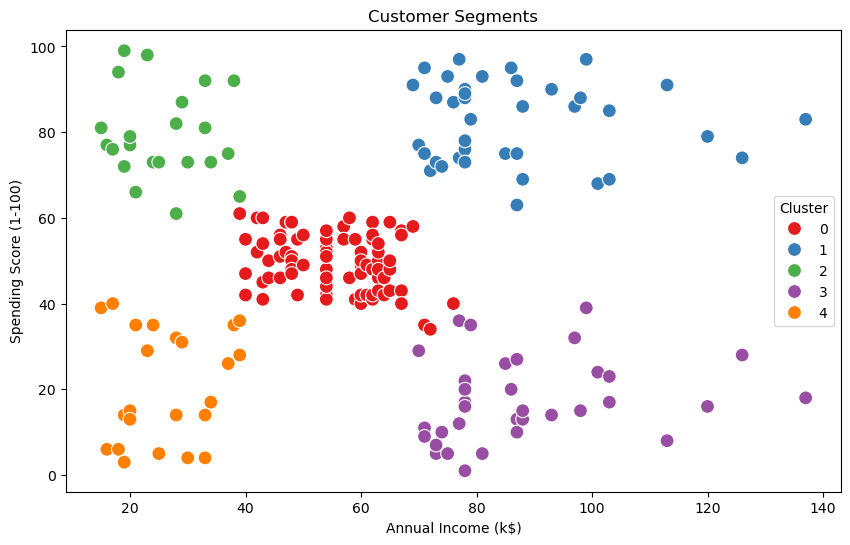

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="Set1",
    s=100
)

plt.title("Customer Segments")

plt.show()

Cluster Evaluation

In [16]:
# Silhouette Score
sil_score = silhouette_score(
    X_scaled,
    clusters
)

print(
    "Silhouette Score:",
    sil_score
)

Silhouette Score: 0.5546571631111091


In [17]:
# Davies-Bouldin Score
db_score = davies_bouldin_score(
    X_scaled,
    clusters
)

print(
    "Davies-Bouldin Score:",
    db_score
)

Davies-Bouldin Score: 0.5722356162263352


In [18]:
# Cluster Summary
cluster_summary = df.groupby(
    "Cluster"
)[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


Business Insights

In [19]:
cluster_counts = df["Cluster"].value_counts()

cluster_counts

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

Pie Chart

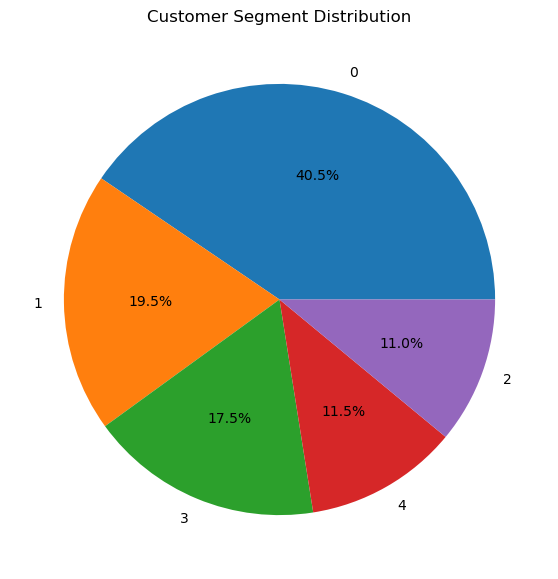

In [20]:
plt.figure(figsize=(7,7))

plt.pie(
    cluster_counts,
    labels=cluster_counts.index,
    autopct="%1.1f%%"
)

plt.title("Customer Segment Distribution")

plt.show()

K-Means Scratch Comparison

In [21]:
from src.ml_algorithms.kmeans import KMeansScratch

ModuleNotFoundError: No module named 'src'

In [ ]:
scratch_model = KMeansScratch(k=5)

scratch_model.fit(X_scaled)

print("Scratch K-Means Completed")

Recommendation Basics

In [ ]:
premium = df[
    (df["Cluster"] == 1)
]

premium.head()

Customer Lifetime Value (Simple)

In [ ]:
df["Estimated_CLV"] = (
    df["Annual Income (k$)"]
    *
    df["Spending Score (1-100)"]
)

df[
    [
        "CustomerID",
        "Estimated_CLV"
    ]
].head()

Top CLV Customers

In [ ]:
top_customers = df.sort_values(
    "Estimated_CLV",
    ascending=False
)

top_customers.head(10)

Final Summary

# Customer Segmentation Summary

Steps Completed:

- Dataset Exploration
- Missing Value Analysis
- Gender Encoding
- Feature Scaling
- Elbow Method
- K-Means Clustering
- Cluster Visualization
- Silhouette Score Evaluation
- Davies-Bouldin Evaluation
- Customer Lifetime Value Estimation
- Basic Recommendation Analysis

Key Findings:

- Optimal clusters: 5
- High-income high-spending customers identified.
- Customer segments can support targeted marketing campaigns.